<a href="https://colab.research.google.com/github/ellal8353/Plan-A/blob/main/Sephora_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What Differentiates Prestige Skincare?

### An exploration of pricing, consumer perception, and brand positioning

## Background

Prestige skincare products span a wide range of prices, from accessible formulas to products costing several hundred dollars. Yet it is not immediately clear whether these price differences correspond with higher customer satisfaction or greater consumer attention.

This project uses product-level Sephora data to investigate how price, category, ingredient positioning, and brand relate to two dimensions of consumer perception:

- **Reported satisfaction**, measured through customer ratings
- **Consumer attention**, measured through Sephora Loves

The analysis begins by testing whether higher prices correspond with stronger customer outcomes. It then examines product characteristics before exploring whether differences are more pronounced at the brand level.

## Business Questions

This analysis addresses four questions:

1. **Does paying more lead to greater customer satisfaction?**
2. **Do consumers pay more attention to more expensive products?**
3. **Do objective product characteristics—such as category and ingredient profile—differentiate consumer outcomes?**
4. **If product characteristics explain relatively little, what role does brand positioning play?**

## Data Source

The analysis uses the publicly available **Sephora Products and Skincare Reviews** dataset published by Nady Inky on Kaggle.

The original dataset contains Sephora product and review information. Before beginning the Python analysis, the data were cleaned in Microsoft Excel and filtered to include core facial skincare products only.

The final analytical dataset contains product-level information including:

- Product and brand name
- Price in USD
- Average customer rating
- Review count
- Sephora Loves
- Product category
- Ingredient list

Throughout this project, **Sephora Loves are treated as a proxy for consumer attention and aspiration**, not as a direct measure of purchases or revenue.

In [60]:
# Core data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Statistical analysis
from scipy.stats import pearsonr, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

# Display preferences
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
import pandas as pd

FILE_PATH = "/content/drive/MyDrive/Sephora Project/Sephora_Data.xlsx"

df = pd.read_excel(FILE_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 1,569
Columns: 10


,product_name,brand_name,loves_count,rating,reviews,ingredients,price_usd,primary_category,secondary_category,tertiary_category
0,The Concentrate Serum,La Mer,7514,4.519,563.000,"['Cyclopentasiloxane, Algae Extract, Glycerin,...",425.000,Skincare,Treatments,Face Serums
1,The Regenerating Serum,La Mer,5356,4.375,152.000,"['Water\\Aqua\\Eau, Algae (Seaweed) Extract, D...",410.000,Skincare,Treatments,Face Serums
2,Ultimate Revival Cream,SK-II,3031,4.467,60.000,"['Aqua (Water), Glycerin, Galactomyces Ferment...",400.000,Skincare,Moisturizers,Moisturizers
3,Super Anti-Aging Night Cream,Dr. Barbara Sturm,218,NaN,NaN,"['Aqua/Water/Eau, Coco-Caprylate/Caprate, Cety...",395.000,Skincare,Moisturizers,Moisturizers
4,The Serum with TFC8,Augustinus Bader,2556,3.988,81.000,"['Aqua/Water/Eau, Glycerin, 1,2-Hexanediol, Ce...",390.000,Skincare,Treatments,Face Serums


In [63]:
# Validate expected columns

expected_columns = [
    "product_name",
    "brand_name",
    "loves_count",
    "rating",
    "reviews",
    "ingredients",
    "price_usd",
    "primary_category",
    "secondary_category",
    "tertiary_category"
]

missing_columns = [
    column for column in expected_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"The following expected columns are missing: {missing_columns}"
    )

# Keep columns in a consistent order
df = df[expected_columns].copy()

# Ensure numeric columns are stored correctly
numeric_columns = [
    "loves_count",
    "rating",
    "reviews",
    "price_usd"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Create the log-transformed Loves variable
df["log_loves"] = np.log1p(df["loves_count"])

print("Dataset validated successfully.")
print(f"Products: {len(df):,}")
print(f"Brands: {df['brand_name'].nunique()}")
print(f"Secondary categories: {df['secondary_category'].nunique()}")

Dataset validated successfully.
Products: 1,569
Brands: 112
Secondary categories: 5


# Data Validation

## Validation Summary

This analysis uses a cleaned subset of the public Sephora Products & Skincare Reviews dataset from Kaggle, filtered to prestige skincare products.

Validation checks confirm:

- 1,569 skincare products
- 112 brands
- 5 secondary product categories
- Numeric variables successfully imported
- Consumer attention transformed using `log(Loves + 1)` to reduce right-skew

These checks ensure the dataset is suitable for exploratory and regression analysis.

In [64]:
validation_summary = pd.DataFrame({
    "Metric": [
        "Products",
        "Brands",
        "Secondary Categories",
        "Average Price (USD)",
        "Average Rating",
        "Average Loves"
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['brand_name'].nunique()}",
        f"{df['secondary_category'].nunique()}",
        f"${df['price_usd'].mean():.2f}",
        f"{df['rating'].mean():.2f}",
        f"{df['loves_count'].mean():,.0f}"
    ]
})

validation_summary

,Metric,Value
0,Products,"1,569"
1,Brands,112
2,Secondary Categories,5
3,Average Price (USD),$61.99
4,Average Rating,4.28
5,Average Loves,"29,628"


# Market Overview

Before testing the research questions, the distributions of price, customer ratings, and Sephora Loves are examined.

These measures represent three different dimensions of the prestige skincare market:

- **Price** reflects market positioning.
- **Customer ratings** reflect reported post-purchase satisfaction.
- **Sephora Loves** reflect consumer attention or expressed interest.

Because Loves are highly right-skewed, the analysis uses `log(Loves + 1)` where appropriate.

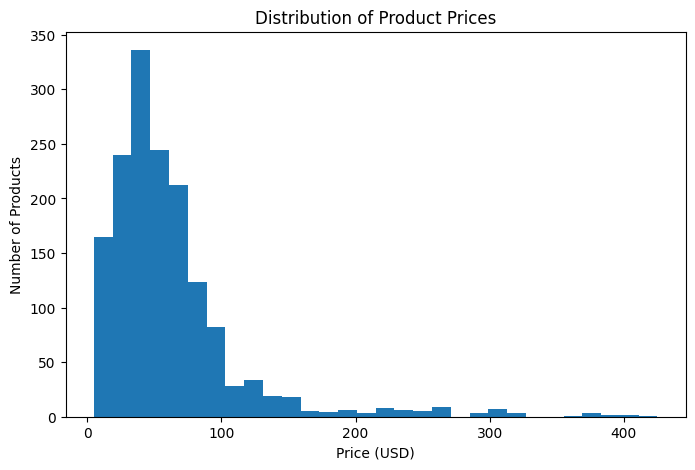

In [65]:
plt.figure(figsize=(8,5))

plt.hist(df["price_usd"], bins=30)

plt.title("Distribution of Product Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Products")

plt.show()

### Observation

Product prices span a wide range, from under $10 to more than $400.

Most products are concentrated below approximately $100, with a relatively small number of ultra-premium products extending the upper tail of the distribution.

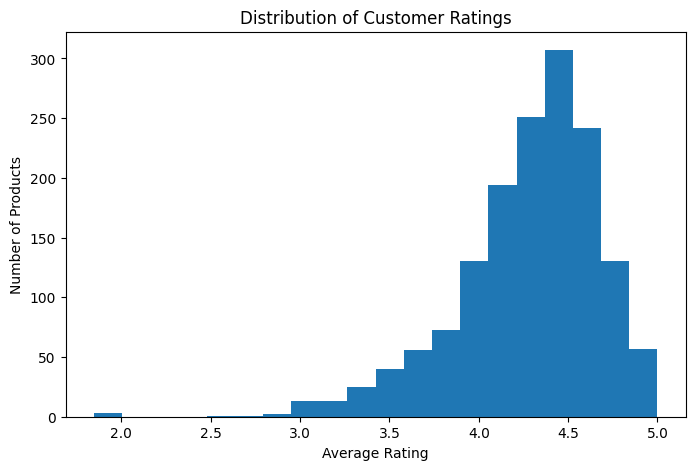

In [66]:
plt.figure(figsize=(8,5))

plt.hist(df["rating"].dropna(), bins=20)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Products")

plt.show()

### Observation

Customer ratings are tightly clustered between approximately 4.0 and 5.0 stars.

This limited variation suggests that prestige skincare products generally receive consistently positive reviews, making it unlikely that customer satisfaction alone explains differences between brands.

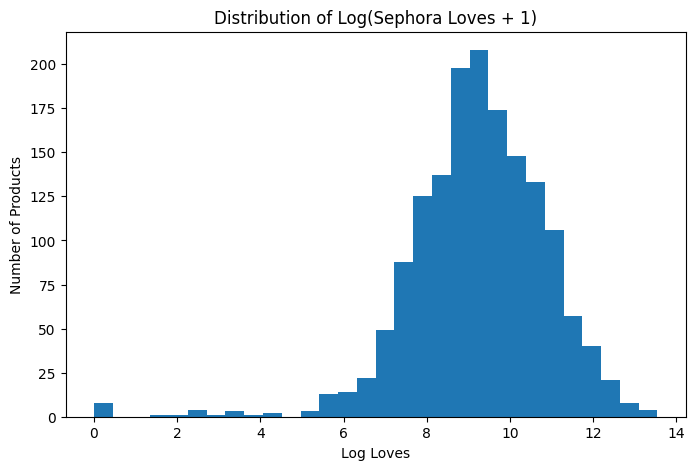

In [67]:
plt.figure(figsize=(8,5))

plt.hist(df["log_loves"], bins=30)

plt.title("Distribution of Log(Sephora Loves + 1)")
plt.xlabel("Log Loves")
plt.ylabel("Number of Products")

plt.show()

### Observation

Consumer attention varies substantially across products.

Unlike ratings, Sephora Loves display considerable dispersion, suggesting that consumers concentrate attention on a relatively small subset of products and brands.

# Research Question 1

## Does paying more lead to greater customer satisfaction?

A common assumption in prestige skincare is that higher-priced products deliver superior customer experiences.

To test this, price is compared with average customer rating using visual exploration, correlation analysis, and linear regression.

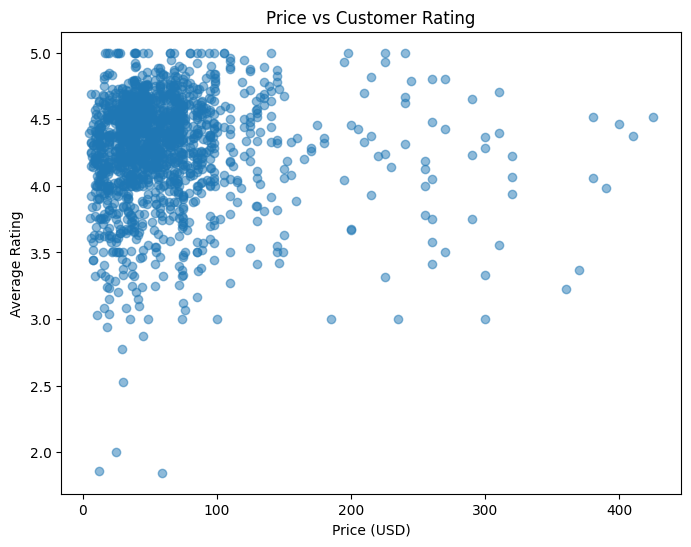

In [68]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["price_usd"],
    df["rating"],
    alpha=0.5
)

plt.title("Price vs Customer Rating")
plt.xlabel("Price (USD)")
plt.ylabel("Average Rating")

plt.show()

In [69]:
from scipy.stats import pearsonr

price_rating = df[["price_usd","rating"]].dropna()

r, p = pearsonr(
    price_rating["price_usd"],
    price_rating["rating"]
)

print(f"Correlation: {r:.3f}")
print(f"P-value: {p:.4f}")

Correlation: 0.008
P-value: 0.7663


In [70]:
model_rating = smf.ols(
    "rating ~ price_usd",
    data=price_rating
).fit()

In [71]:
rating_summary = pd.DataFrame({
    "Metric": [
        "Pearson Correlation (r)",
        "Correlation p-value",
        "Regression R²",
        "Regression p-value"
    ],
    "Value": [
        f"{r:.3f}",
        f"{p:.3f}",
        f"{model_rating.rsquared:.3f}",
        f"{model_rating.pvalues['price_usd']:.3f}"
    ]
})

rating_summary

,Metric,Value
0,Pearson Correlation (r),0.008
1,Correlation p-value,0.766
2,Regression R²,0.000
3,Regression p-value,0.766


Findings
Customer ratings remain consistently high across the prestige skincare market.
The correlation between price and rating is effectively zero (r = 0.008), and the regression explains virtually none of the variation in customer ratings (R² ≈ 0.000).
Although premium-priced products often receive high ratings, similarly high ratings are observed across substantially lower price points.
Conclusion: Higher prices do not consistently correspond with higher reported customer satisfaction.

# Research Question 2

## Do consumers pay more attention to more expensive products?

Customer satisfaction is only one dimension of consumer perception. Premium products may not receive higher ratings, but they may still attract greater consumer attention.

To explore this question, consumer attention is measured using **Sephora Loves**.

Because Loves are highly right-skewed, the analysis uses **log(Loves + 1)**, which provides a more appropriate distribution for correlation and regression analysis.

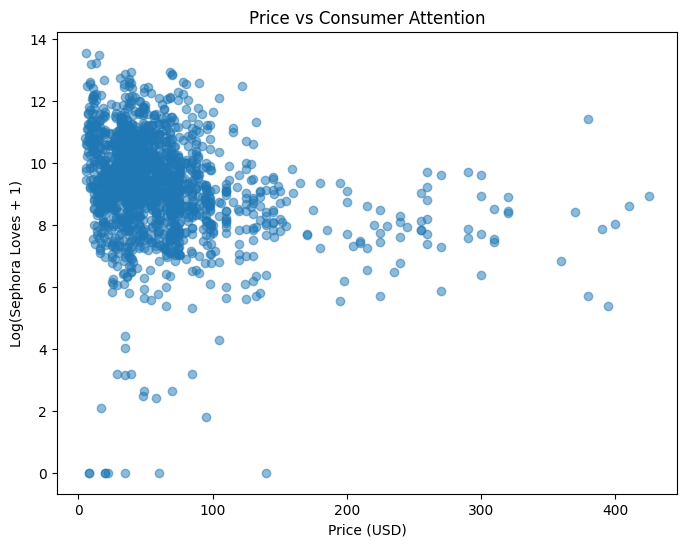

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["price_usd"],
    df["log_loves"],
    alpha=0.5
)

plt.title("Price vs Consumer Attention")
plt.xlabel("Price (USD)")
plt.ylabel("Log(Sephora Loves + 1)")

plt.show()

In [73]:
price_loves = df[["price_usd", "log_loves"]].dropna()

r_loves, p_loves = pearsonr(
    price_loves["price_usd"],
    price_loves["log_loves"]
)

print(f"Correlation: {r_loves:.3f}")
print(f"P-value: {p_loves:.4f}")

Correlation: -0.230
P-value: 0.0000


In [74]:
model_loves = smf.ols(
    "log_loves ~ price_usd",
    data=price_loves
).fit()

In [75]:
loves_summary = pd.DataFrame({
    "Metric": [
        "Pearson Correlation (r)",
        "Correlation p-value",
        "Regression R²",
        "Regression p-value"
    ],
    "Value": [
        f"{r_loves:.3f}",
        f"{p_loves:.3f}",
        f"{model_loves.rsquared:.3f}",
        f"{model_loves.pvalues['price_usd']:.3f}"
    ]
})

loves_summary

,Metric,Value
0,Pearson Correlation (r),-0.230
1,Correlation p-value,0.000
2,Regression R²,0.053
3,Regression p-value,0.000


### Findings

Price exhibits a weak negative relationship with consumer attention (Pearson r = -0.230).

Although the relationship is statistically significant (p < 0.001), price explains only a small proportion of the variation in Sephora Loves (R² = 0.053).

This suggests that more expensive products do not necessarily attract greater consumer attention. Instead, factors beyond price appear to play a much larger role in determining which products receive the most consumer engagement.

**Conclusion:** Price alone is a relatively weak predictor of consumer attention.

# Research Question 3

## Do objective product characteristics explain consumer perception?

Price explains relatively little of the variation in customer satisfaction and consumer attention.

The next step is to investigate whether objective product characteristics—including product category and ingredient profile—better explain consumer outcomes.

This section evaluates whether different skincare categories or commonly marketed ingredient families are associated with differences in price, customer ratings, or consumer attention.

In [76]:
category_summary = (
    df.groupby("secondary_category")
      .agg(
          Products=("product_name","count"),
          Avg_Price=("price_usd","mean"),
          Avg_Rating=("rating","mean"),
          Avg_Loves=("loves_count","mean")
      )
      .round(2)
      .sort_values("Avg_Price", ascending=False)
)

category_summary

,Products,Avg_Price,Avg_Rating,Avg_Loves
secondary_category,,,,
Moisturizers,477,74.840,4.280,"25,414.580"
Eye Care,172,68.820,4.120,"22,131.780"
Treatments,457,68.010,4.310,"36,194.190"
Masks,127,50.740,4.290,"36,179.180"
Cleansers,336,36.340,4.320,"28,039.780"


### Category Findings

Average prices differ across skincare categories, although customer ratings remain consistently high regardless of category.

Consumer attention varies somewhat across product categories, although these differences are modest relative to those observed across brands.

Category therefore appears to explain only a limited share of consumer outcomes.

In [77]:
# Define commonly marketed ingredient families and the terms used to detect them

ingredient_patterns = {
    "Peptides": r"peptide",
    "Ferments": r"ferment|lysate|galactomyces|bifida",
    "Vitamin C": (
        r"ascorbic acid|ascorbyl|"
        r"tetrahexyldecyl ascorbate|"
        r"2-o-ethyl ascorbic acid"
    ),
    "Hyaluronic Acid": r"hyaluronic acid|sodium hyaluronate",
    "Ceramides": r"ceramide",
    "Antioxidants": (
        r"resveratrol|tocopherol|"
        r"camellia sinensis|ubiquinone"
    ),
    "BHAs": r"salicylic acid",
    "Squalane": r"squalane|squalene",
    "Niacinamide": r"niacinamide|niacin",
    "Retinoids": r"retinol|retinal|retinyl",
    "AHAs": (
        r"glycolic acid|lactic acid|"
        r"mandelic acid|gluconolactone"
    )
}

ingredient_columns = {}

for ingredient_name, pattern in ingredient_patterns.items():
    column_name = (
        "contains_"
        + ingredient_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    df[column_name] = (
        df["ingredients"]
        .astype("string")
        .str.contains(
            pattern,
            case=False,
            na=False,
            regex=True
        )
    )

    ingredient_columns[ingredient_name] = column_name

print("Ingredient indicators created successfully.")

Ingredient indicators created successfully.


In [78]:
# Compare products with and without each ingredient family

ingredient_test_rows = []

outcomes = {
    "Price": "price_usd",
    "Rating": "rating",
    "Consumer Attention": "log_loves"
}

for ingredient_name, column_name in ingredient_columns.items():

    for outcome_name, outcome_column in outcomes.items():

        with_ingredient = (
            df.loc[df[column_name], outcome_column]
            .dropna()
        )

        without_ingredient = (
            df.loc[~df[column_name], outcome_column]
            .dropna()
        )

        statistic, p_value = mannwhitneyu(
            with_ingredient,
            without_ingredient,
            alternative="two-sided"
        )

        ingredient_test_rows.append({
            "Ingredient Family": ingredient_name,
            "Outcome": outcome_name,
            "Products With Ingredient": len(with_ingredient),
            "Median With": with_ingredient.median(),
            "Median Without": without_ingredient.median(),
            "Median Difference": (
                with_ingredient.median()
                - without_ingredient.median()
            ),
            "P-value": p_value
        })

ingredient_tests = pd.DataFrame(ingredient_test_rows)

# Adjust for multiple comparisons
ingredient_tests["Adjusted P-value"] = multipletests(
    ingredient_tests["P-value"],
    method="fdr_bh"
)[1]

ingredient_tests["Statistically Significant"] = (
    ingredient_tests["Adjusted P-value"] < 0.05
)

ingredient_results = (
    ingredient_tests[
        [
            "Ingredient Family",
            "Outcome",
            "Products With Ingredient",
            "Median Difference",
            "Adjusted P-value",
            "Statistically Significant"
        ]
    ]
    .sort_values(
        ["Outcome", "Adjusted P-value"]
    )
)

ingredient_results.round(4)

,Ingredient Family,Outcome,Products With Ingredient,Median Difference,Adjusted P-value,Statistically Significant
2,Peptides,Consumer Attention,332,-0.282,0.006,True
5,Ferments,Consumer Attention,460,-0.258,0.010,True
8,Vitamin C,Consumer Attention,416,-0.155,0.059,False
11,Hyaluronic Acid,Consumer Attention,726,-0.155,0.210,False
14,Ceramides,Consumer Attention,165,0.159,0.299,False
17,Antioxidants,Consumer Attention,830,-0.048,0.299,False
20,BHAs,Consumer Attention,185,0.093,0.471,False
23,Squalane,Consumer Attention,415,0.033,0.560,False
26,Niacinamide,Consumer Attention,258,-0.120,0.562,False
29,Retinoids,Consumer Attention,117,0.060,0.935,False


In [79]:
ingredient_significance_summary = (
    ingredient_tests
    .groupby("Outcome")
    .agg(
        Ingredient_Families_Tested=(
            "Ingredient Family",
            "count"
        ),
        Significant_Differences=(
            "Statistically Significant",
            "sum"
        )
    )
    .reset_index()
)

ingredient_significance_summary

,Outcome,Ingredient_Families_Tested,Significant_Differences
0,Consumer Attention,11,2
1,Price,11,9
2,Rating,11,4


### Ingredient Findings

Ingredient families are much more consistently associated with product pricing than with consumer attention.

After adjusting for multiple comparisons, 9 of the 11 ingredient families tested showed significant price differences. Most were associated with higher median prices, while products containing BHAs had a lower median price.

Four ingredient families showed statistically significant differences in customer ratings. However, these differences were small in practical terms, with median rating differences of approximately 0.06 to 0.12 stars.

Only two ingredient families—peptides and ferments—showed significant differences in consumer attention, and both were associated with slightly lower log-transformed Sephora Loves.

These results should not be interpreted as evidence that particular ingredients cause higher prices, ratings, or attention. Products contain multiple ingredients, and the analysis identifies market associations rather than clinical efficacy or causal effects.

**Conclusion:** Ingredient profile is strongly associated with how prestige skincare products are priced, but it explains comparatively little of the variation in consumer attention and only small differences in reported satisfaction.

# Research Question 4

## Does brand matter more than product characteristics?

The previous analyses suggest that price, category, and ingredient profile explain only a limited share of the variation in customer satisfaction and consumer attention.

The final step is to test whether brand explains substantially more variation than objective product characteristics.

This analysis compares the explanatory power of brand and category in predicting:

- Product price
- Customer ratings
- Consumer attention (Sephora Loves)

If brand explains substantially more variation than measurable product characteristics, this would suggest that brand positioning plays an important role within the prestige skincare market.

In [80]:
brand_models = {
    "Price": smf.ols("price_usd ~ C(brand_name)", data=df).fit(),
    "Rating": smf.ols("rating ~ C(brand_name)", data=df).fit(),
    "Consumer Attention": smf.ols("log_loves ~ C(brand_name)", data=df).fit()
}

category_models = {
    "Price": smf.ols("price_usd ~ C(secondary_category)", data=df).fit(),
    "Rating": smf.ols("rating ~ C(secondary_category)", data=df).fit(),
    "Consumer Attention": smf.ols("log_loves ~ C(secondary_category)", data=df).fit()
}

comparison = pd.DataFrame({
    "Outcome": ["Price", "Rating", "Consumer Attention"],
    "Category R²": [
        category_models["Price"].rsquared,
        category_models["Rating"].rsquared,
        category_models["Consumer Attention"].rsquared
    ],
    "Brand R²": [
        brand_models["Price"].rsquared,
        brand_models["Rating"].rsquared,
        brand_models["Consumer Attention"].rsquared
    ]
})

comparison = comparison.round(3)

comparison

,Outcome,Category R²,Brand R²
0,Price,0.076,0.599
1,Rating,0.021,0.211
2,Consumer Attention,0.005,0.420


## Findings

Brand membership consistently explains substantially more variation than objective product characteristics across every outcome examined.

For product pricing, brand accounts for approximately 60% of the observed variation, compared with only 8% for category.

Similarly, brand explains much more variation in consumer attention, while customer ratings remain consistently high across the prestige skincare market.

Overall, these results suggest that brand positioning is much more strongly associated with premium pricing and consumer attention than objective product characteristics alone.

# Conclusion

## Key Findings

This analysis examined whether product price, category, ingredient profile, and brand explain differences in consumer perception across prestige skincare products sold at Sephora.

The results suggest four main findings:

- Paying more does not consistently lead to higher customer ratings.
- Price alone explains relatively little of the variation in consumer attention.
- Product category explains relatively little variation in customer outcomes, while ingredient families are much more strongly associated with pricing than with customer satisfaction or consumer attention.
- Brand membership explains substantially more variation in premium pricing and consumer attention than objective product characteristics.

Overall, the analysis suggests that prestige skincare products are differentiated less by measurable product characteristics than by brand positioning. While prices vary substantially across the market, customer satisfaction remains consistently high, and consumer attention is concentrated around a relatively small number of brands.

These findings illustrate how publicly available consumer data can be used to generate commercially relevant insights into pricing, consumer perception, and brand positioning.

## Business Implications

These findings suggest that prestige skincare brands compete less through measurable differences in reported customer satisfaction and more through successful brand positioning.

Although customer ratings remain consistently high across the market, brands differ substantially in both pricing and consumer attention. This implies that intangible factors—such as brand equity, marketing, heritage, product storytelling, and consumer trust—may play a larger commercial role than observable product characteristics alone.

For merchandising and commercial strategy teams, these results suggest that strengthening brand perception may have a greater impact on market performance than incremental changes to product formulation.

## Limitations

This analysis is observational and does not establish causal relationships.

In addition, Sephora Loves measures consumer attention and engagement rather than purchases or revenue, while customer ratings reflect reported satisfaction rather than objective product performance.

Future work could incorporate sales data, repeat purchase behavior, or longitudinal product performance to better understand how brand equity influences commercial success.